<a href="https://colab.research.google.com/github/Artjon278/Machine-Learning-/blob/main/machine_leaning01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import os
from pathlib import Path
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, roc_auc_score)
import kagglehub
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.


In [9]:
print(tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print(gpus)

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
DATA = Path(path)
print(os.listdir(DATA))

['test', 'train']


In [11]:
train_dir, test_dir = DATA/'train', DATA/'test'

for d in [train_dir/'REAL', train_dir/'FAKE', test_dir/'REAL', test_dir/'FAKE']:
    print(d.name, len(list(d.glob('*.jpg'))))

REAL 50000
FAKE 50000
REAL 10000
FAKE 10000


(32, 32, 3) 0.0 219.0


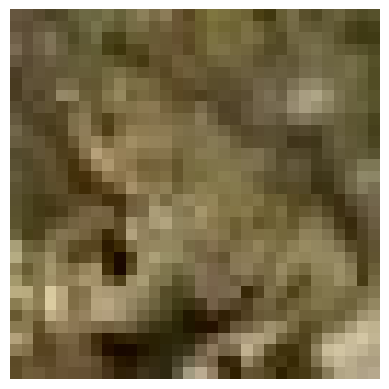

In [12]:
sample = next((train_dir/'REAL').glob('*.jpg'))
arr = tf.keras.utils.img_to_array(tf.keras.utils.load_img(sample))
print(arr.shape, arr.min(), arr.max())
plt.imshow(arr.astype('uint8')); plt.axis('off'); plt.show()

In [13]:
IMG, BATCH = (32, 32), 128
common = dict(image_size=IMG, batch_size=BATCH, label_mode='binary')

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.1, subset='training', seed=42,
    shuffle=True, **common)
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.1, subset='validation', seed=42,
    shuffle=True, **common)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, shuffle=False, **common)

class_names = train_ds.class_names
print(class_names)   # ['FAKE', 'REAL'] -> FAKE=0, REAL=1

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

Found 100000 files belonging to 2 classes.
Using 90000 files for training.
Found 100000 files belonging to 2 classes.
Using 10000 files for validation.
Found 20000 files belonging to 2 classes.
['FAKE', 'REAL']


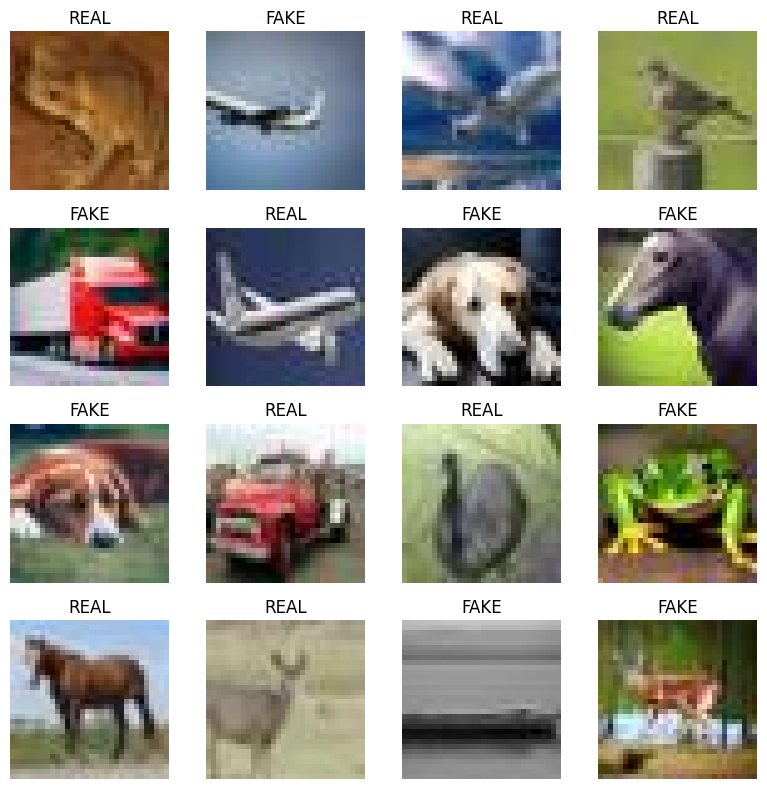

In [14]:
imgs, labels = next(iter(train_ds))
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(imgs[i].numpy().astype('uint8'))
    plt.title(class_names[int(labels[i])]); plt.axis('off')
plt.tight_layout(); plt.show()

In [15]:
from tensorflow.keras import layers, models

def block(x, f):
    for _ in range(2):
        x = layers.Conv2D(f, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    return layers.MaxPooling2D()(x)

inp = layers.Input((32, 32, 3))
x = layers.Rescaling(1./255)(inp)
x = layers.RandomFlip('horizontal')(x)
for f in (32, 64, 128):
    x = block(x, f)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inp, out)
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 550,753 (2.10 MB)

 Trainable params: 549,857 (2.10 MB)

 Non-trainable params: 896 (3.50 KB)

In [16]:
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2,
                                      restore_best_weights=True)
history = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[es])
model.save('/content/cifake_cnn.keras')

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 51ms/step - accuracy: 0.8892 - auc: 0.9531 - loss: 0.2871 - val_accuracy: 0.9242 - val_auc: 0.9753 - val_loss: 0.2019
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9344 - auc: 0.9798 - loss: 0.1816 - val_accuracy: 0.9308 - val_auc: 0.9807 - val_loss: 0.1889
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9435 - auc: 0.9849 - loss: 0.1564 - val_accuracy: 0.9203 - val_auc: 0.9846 - val_loss: 0.2129
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9499 - auc: 0.9871 - loss: 0.1431 - val_accuracy: 0.9277 - val_auc: 0.9837 - val_loss: 0.1861
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9542 - auc: 0.9894 - loss: 0.1294 - val_accuracy: 0.9207 - val_auc: 0.9866 - val_loss: 0.2236
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9575 - auc: 0.9906 - loss: 0.1201 - val_accuracy: 0.9481 - val_auc: 0.9911 - val_loss: 0.1344
Epoch 7/10
704/704 ━━━━━━━━━

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


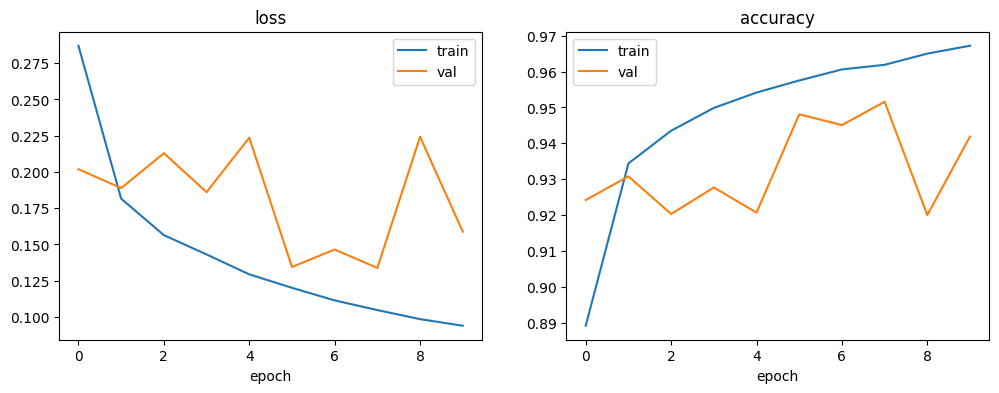

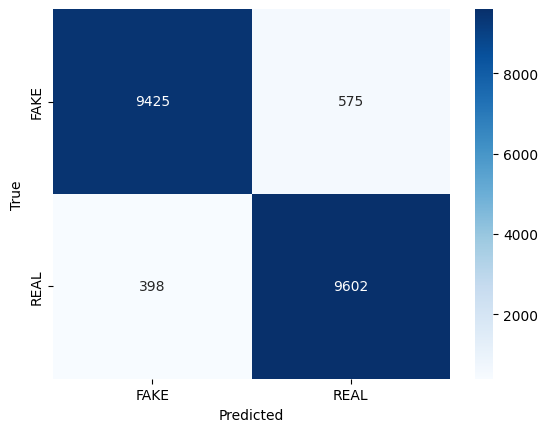

              precision    recall  f1-score   support

        FAKE       0.96      0.94      0.95     10000
        REAL       0.94      0.96      0.95     10000

    accuracy                           0.95     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.95      0.95      0.95     20000



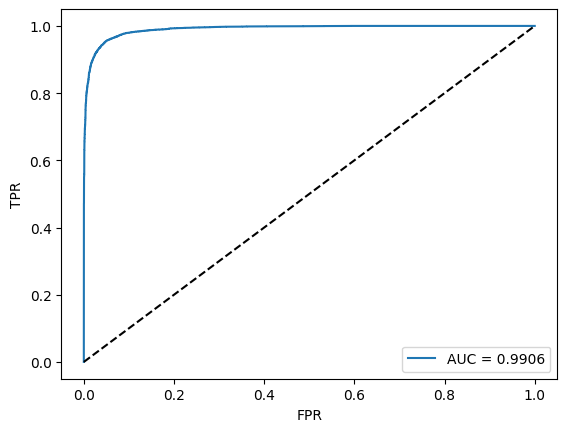

In [17]:
y_true = np.concatenate([y for _, y in test_ds]).ravel()
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob > 0.5).astype(int)

h = history.history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, m in enumerate(['loss', 'accuracy']):
    ax[i].plot(h[m], label='train'); ax[i].plot(h['val_'+m], label='val')
    ax[i].set_title(m); ax[i].set_xlabel('epoch'); ax[i].legend()
plt.show()

sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_true, y_prob):.4f}')
plt.plot([0, 1], [0, 1], 'k--'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.legend(); plt.show()